In [1]:
# Install required packages
import subprocess
import sys

packages = [
    'pandas',
    'numpy',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'tensorflow',
    'imbalanced-learn'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ All packages installed successfully!")

✓ All packages installed successfully!


In [3]:
# Import Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

✓ Libraries imported successfully!
Pandas version: 2.2.2
Scikit-learn version: 1.6.1


In [4]:
# Create a realistic synthetic dataset mimicking UNSW-NB15 structure
# This serves as a proof-of-concept; in production, use the actual UNSW-NB15 dataset

np.random.seed(42)

# Number of samples
n_normal = 3000
n_attack = 1000
n_total = n_normal + n_attack

# Generate normal traffic (Label: 0)
normal_data = {
    'srcip_bytes': np.random.normal(5000, 1000, n_normal),
    'dstip_bytes': np.random.normal(4000, 800, n_normal),
    'duration': np.random.exponential(1.5, n_normal),
    'protocol': np.random.choice(['tcp', 'udp', 'icmp'], n_normal),
    'service': np.random.choice(['http', 'https', 'ssh', 'dns', 'ftp'], n_normal),
    'flag': np.random.choice(['CON', 'FIN', 'REQ', 'RST', 'SYN'], n_normal),
    'src_port': np.random.randint(1024, 65535, n_normal),
    'dst_port': np.random.randint(1, 1024, n_normal),
    'packet_count': np.random.poisson(50, n_normal),
    'packet_rate': np.random.normal(100, 20, n_normal),
    'label': 0
}

# Generate attack traffic (Label: 1) - with anomalous characteristics
attack_data = {
    'srcip_bytes': np.random.normal(15000, 3000, n_attack),  # Higher bytes
    'dstip_bytes': np.random.normal(1000, 500, n_attack),     # Lower destination bytes
    'duration': np.random.exponential(0.5, n_attack),          # Shorter duration
    'protocol': np.random.choice(['tcp', 'udp', 'icmp'], n_attack, p=[0.6, 0.3, 0.1]),
    'service': np.random.choice(['http', 'https', 'ssh', 'dns', 'ftp'], n_attack, p=[0.4, 0.3, 0.2, 0.05, 0.05]),
    'flag': np.random.choice(['CON', 'FIN', 'REQ', 'RST', 'SYN'], n_attack, p=[0.2, 0.1, 0.2, 0.3, 0.2]),
    'src_port': np.random.randint(1024, 65535, n_attack),
    'dst_port': np.random.choice([22, 80, 443, 53, 21], n_attack),  # Common attack targets
    'packet_count': np.random.poisson(500, n_attack),  # Much higher packet count
    'packet_rate': np.random.normal(1000, 200, n_attack),  # Much higher packet rate
    'label': 1
}

# Combine datasets
df_normal = pd.DataFrame(normal_data)
df_attack = pd.DataFrame(attack_data)
df = pd.concat([df_normal, df_attack], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1).reset_index(drop=True)

print(f"✓ Dataset created successfully!")
print(f"Total samples: {len(df)}")
print(f"Normal traffic (label=0): {(df['label']==0).sum()} samples")
print(f"Attack traffic (label=1): {(df['label']==1).sum()} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nDataset shape: {df.shape}")

✓ Dataset created successfully!
Total samples: 4000
Normal traffic (label=0): 3000 samples
Attack traffic (label=1): 1000 samples

Class distribution:
label
0    3000
1    1000
Name: count, dtype: int64

Dataset shape: (4000, 11)


In [5]:
# Display basic statistics
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset Info:")
print(df.info())
print(f"\nBasic Statistics:")
print(df.describe())

DATASET OVERVIEW

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   srcip_bytes   4000 non-null   float64
 1   dstip_bytes   4000 non-null   float64
 2   duration      4000 non-null   float64
 3   protocol      4000 non-null   object 
 4   service       4000 non-null   object 
 5   flag          4000 non-null   object 
 6   src_port      4000 non-null   int64  
 7   dst_port      4000 non-null   int64  
 8   packet_count  4000 non-null   int64  
 9   packet_rate   4000 non-null   float64
 10  label         4000 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 343.9+ KB
None

Basic Statistics:
        srcip_bytes  dstip_bytes     duration     src_port     dst_port  \
count   4000.000000  4000.000000  4000.000000   4000.00000  4000.000000   
mean    7536.296231  3233.493793     1.202060  33490.41400   419

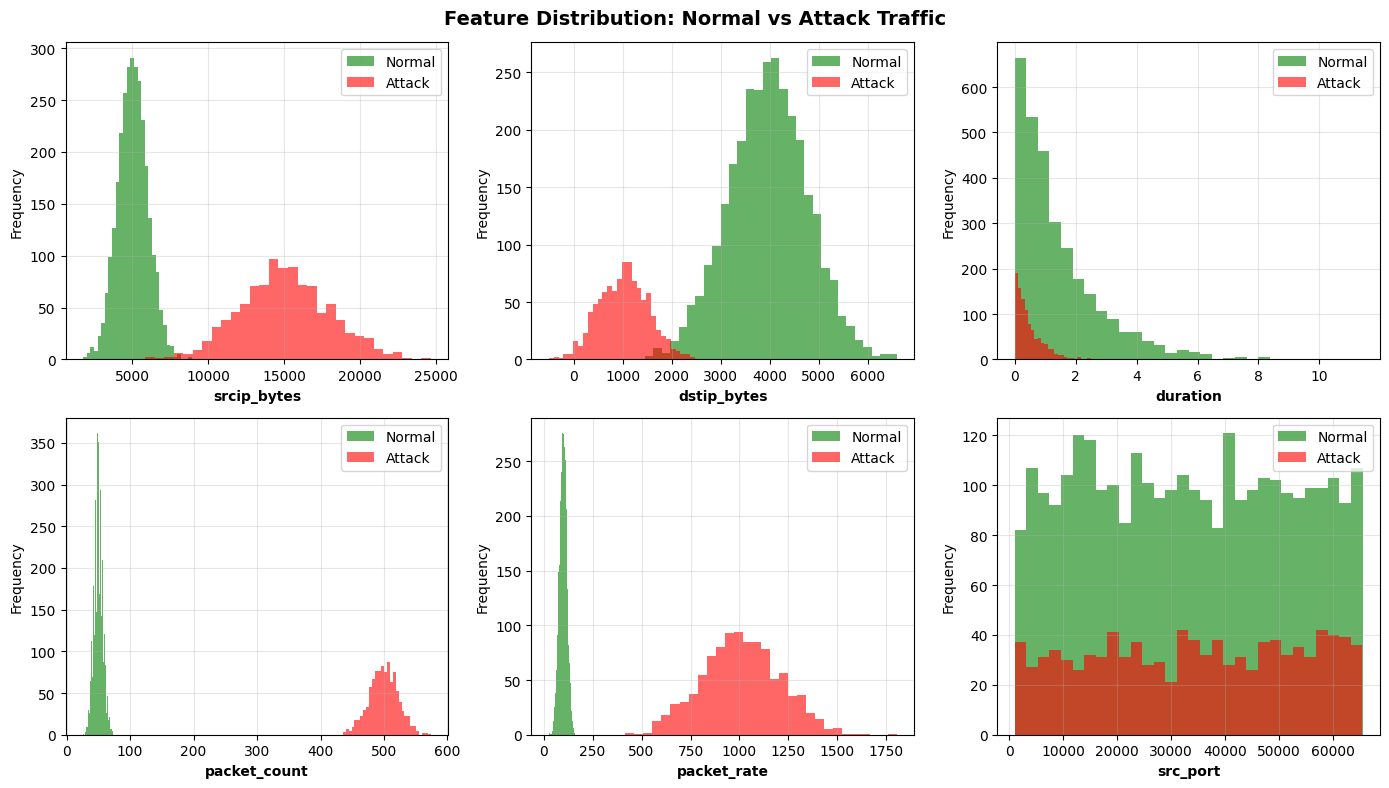

✓ Feature distribution plot saved!


In [6]:
# Analyze feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distribution: Normal vs Attack Traffic', fontsize=14, fontweight='bold')

features_to_plot = ['srcip_bytes', 'dstip_bytes', 'duration', 'packet_count', 'packet_rate', 'src_port']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]

    normal = df[df['label'] == 0][feature]
    attack = df[df['label'] == 1][feature]

    ax.hist(normal, alpha=0.6, bins=30, label='Normal', color='green')
    ax.hist(attack, alpha=0.6, bins=30, label='Attack', color='red')
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_feature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature distribution plot saved!")

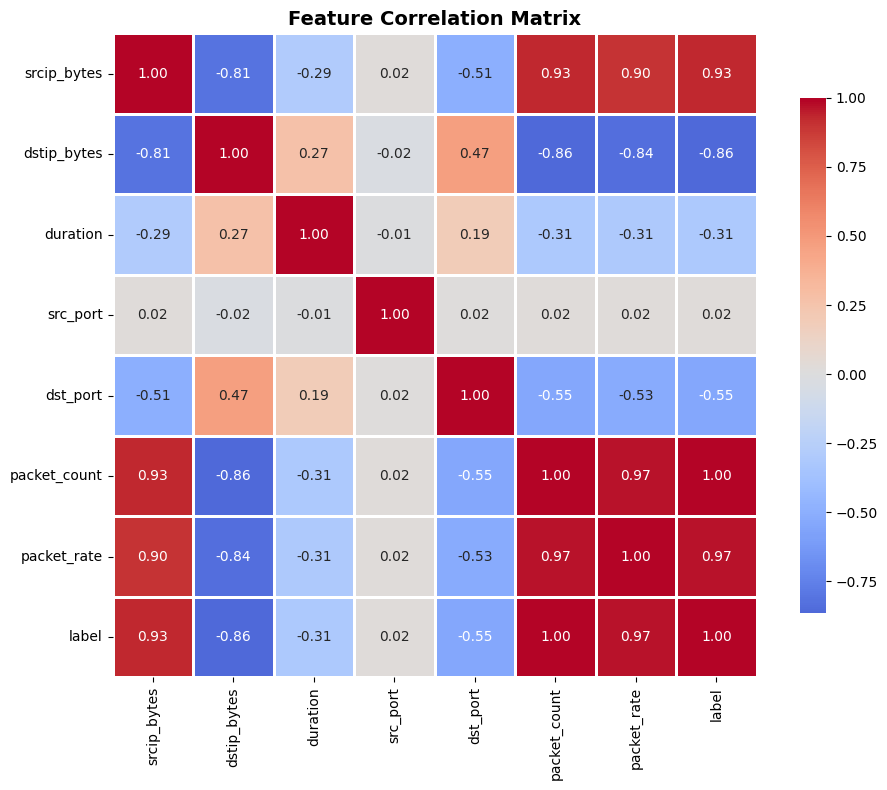

✓ Correlation matrix saved!


In [8]:
# Correlation matrix
# First, select only numeric columns
numeric_df = df[['srcip_bytes', 'dstip_bytes', 'duration', 'src_port', 'dst_port', 'packet_count', 'packet_rate', 'label']].copy()

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation matrix saved!")

In [9]:
# Handle missing values
print("Checking for missing values...")
print(df.isnull().sum())
print("\n✓ No missing values detected!")

Checking for missing values...
srcip_bytes     0
dstip_bytes     0
duration        0
protocol        0
service         0
flag            0
src_port        0
dst_port        0
packet_count    0
packet_rate     0
label           0
dtype: int64

✓ No missing values detected!


In [10]:
# Prepare data for modeling
# Separate features and target
X = df.drop('label', axis=1).copy()
y = df['label'].copy()

# Encode categorical features
categorical_features = ['protocol', 'service', 'flag']
label_encoders = {}

print("Encoding categorical features...")
for feature in categorical_features:
    le = LabelEncoder()
    X[feature] = le.fit_transform(X[feature])
    label_encoders[feature] = le
    print(f"  ✓ {feature}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nFeature set shape after encoding: {X.shape}")
print(f"\nFeatures: {list(X.columns)}")

Encoding categorical features...
  ✓ protocol: {'icmp': np.int64(0), 'tcp': np.int64(1), 'udp': np.int64(2)}
  ✓ service: {'dns': np.int64(0), 'ftp': np.int64(1), 'http': np.int64(2), 'https': np.int64(3), 'ssh': np.int64(4)}
  ✓ flag: {'CON': np.int64(0), 'FIN': np.int64(1), 'REQ': np.int64(2), 'RST': np.int64(3), 'SYN': np.int64(4)}

Feature set shape after encoding: (4000, 10)

Features: ['srcip_bytes', 'dstip_bytes', 'duration', 'protocol', 'service', 'flag', 'src_port', 'dst_port', 'packet_count', 'packet_rate']


In [11]:
# Split dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split summary:")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  Normal: {(y_train==0).sum()} samples")
print(f"  Attack: {(y_train==1).sum()} samples")
print(f"\nTesting set class distribution:")
print(f"  Normal: {(y_test==0).sum()} samples")
print(f"  Attack: {(y_test==1).sum()} samples")

Data split summary:
  Training set: 3200 samples (80.0%)
  Testing set: 800 samples (20.0%)

Training set class distribution:
  Normal: 2400 samples
  Attack: 800 samples

Testing set class distribution:
  Normal: 600 samples
  Attack: 200 samples


In [12]:
# Handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique)
print("\nApplying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:")
print(f"  Training set size: {X_train_balanced.shape[0]}")
print(f"  Normal samples: {(y_train_balanced==0).sum()}")
print(f"  Attack samples: {(y_train_balanced==1).sum()}")
print(f"\n✓ Class imbalance resolved!")


Applying SMOTE to balance training data...
After SMOTE:
  Training set size: 4800
  Normal samples: 2400
  Attack samples: 2400

✓ Class imbalance resolved!


In [13]:
# Normalize numerical features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Feature normalization completed!")
print(f"  Training features shape: {X_train_scaled.shape}")
print(f"  Testing features shape: {X_test_scaled.shape}")
print(f"\n✓ Data preprocessing complete!")

Feature normalization completed!
  Training features shape: (4800, 10)
  Testing features shape: (800, 10)

✓ Data preprocessing complete!


In [15]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_balanced)
print("✓ Random Forest model trained successfully!")

Training Random Forest Classifier...
✓ Random Forest model trained successfully!



Feature Importance (Random Forest):
        feature  importance
9   packet_rate    0.324755
8  packet_count    0.258231
0   srcip_bytes    0.230914
1   dstip_bytes    0.130951
7      dst_port    0.039153
2      duration    0.011726
4       service    0.002796
3      protocol    0.001463
5          flag    0.000008
6      src_port    0.000005


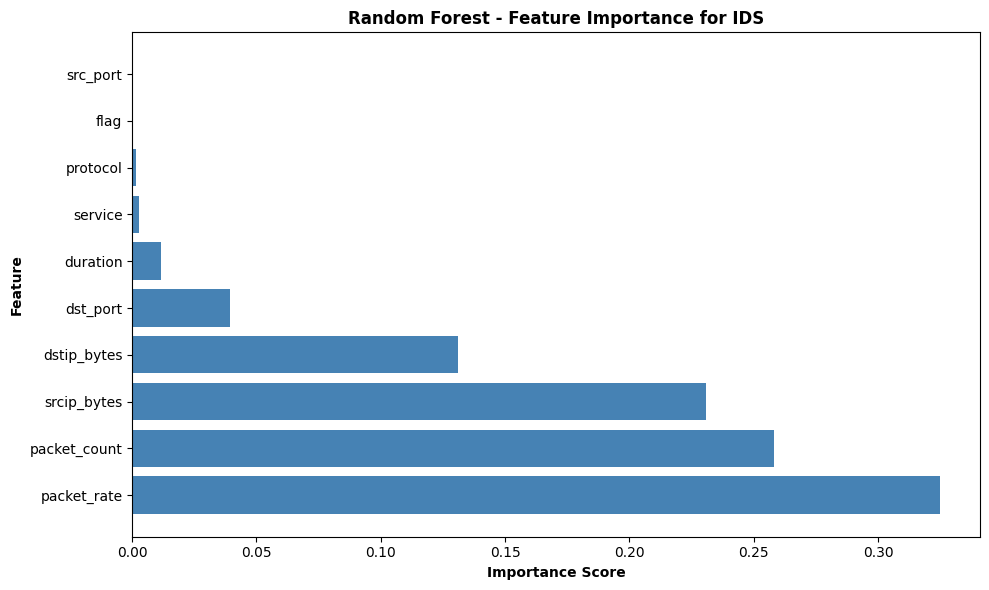


✓ Feature importance visualization saved!


In [16]:
# Display feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.title('Random Forest - Feature Importance for IDS', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance visualization saved!")

In [17]:
# Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train_balanced)
print("✓ Decision Tree model trained successfully!")

Training Decision Tree Classifier...
✓ Decision Tree model trained successfully!


In [18]:
# Train Logistic Regression Classifier
print("Training Logistic Regression Classifier...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train_balanced)
print("✓ Logistic Regression model trained successfully!")

Training Logistic Regression Classifier...
✓ Logistic Regression model trained successfully!


In [19]:
# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
print("="*70)
print("RANDOM FOREST - PERFORMANCE EVALUATION")
print("="*70)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nPERFORMANCE METRICS:")
print(f"  Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"  Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%) - False alarm rate")
print(f"  Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%) - Attack detection rate")
print(f"  F1-Score:  {f1_rf:.4f}")
print(f"  ROC-AUC:   {auc_rf:.4f}")

print(f"\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))

RANDOM FOREST - PERFORMANCE EVALUATION

PERFORMANCE METRICS:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000 (100.00%) - False alarm rate
  Recall:    1.0000 (100.00%) - Attack detection rate
  F1-Score:  1.0000
  ROC-AUC:   1.0000

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       600
      Attack       1.00      1.00      1.00       200

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [20]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nCONFUSION MATRIX:")
print(f"\n                 Predicted Normal  Predicted Attack")
print(f"Actual Normal     {cm_rf[0,0]:>8}           {cm_rf[0,1]:>8}")
print(f"Actual Attack     {cm_rf[1,0]:>8}           {cm_rf[1,1]:>8}")

# Security Analysis
print(f"\n" + "="*70)
print("SECURITY IMPLICATION ANALYSIS (Random Forest)")
print("="*70)

tn, fp, fn, tp = cm_rf.ravel()

print(f"\nTrue Negatives (TN):  {tn}  - Normal traffic correctly identified")
print(f"False Positives (FP): {fp}  - False alarms (normal flagged as attack)")
print(f"False Negatives (FN): {fn}  - CRITICAL: Missed attacks")
print(f"True Positives (TP):  {tp}  - Attacks correctly detected")

print(f"\n🔴 CRITICAL FINDING:")
if fn > 0:
    print(f"   {fn} attacks were MISSED by the system (False Negatives)")
    print(f"   Security Risk: {(fn/(fn+tp))*100:.2f}% of actual attacks went undetected")
else:
    print(f"   ✓ All attacks were detected! No missed intrusions.")

if fp > 0:
    print(f"\n⚠️  {fp} False Alarms raised")
    print(f"   Operational Impact: {(fp/(fp+tn))*100:.2f}% of benign traffic flagged as attacks")
else:
    print(f"\n✓ No false alarms - zero operational overhead")


CONFUSION MATRIX:

                 Predicted Normal  Predicted Attack
Actual Normal          600                  0
Actual Attack            0                200

SECURITY IMPLICATION ANALYSIS (Random Forest)

True Negatives (TN):  600  - Normal traffic correctly identified
False Positives (FP): 0  - False alarms (normal flagged as attack)
False Negatives (FN): 0  - CRITICAL: Missed attacks
True Positives (TP):  200  - Attacks correctly detected

🔴 CRITICAL FINDING:
   ✓ All attacks were detected! No missed intrusions.

✓ No false alarms - zero operational overhead


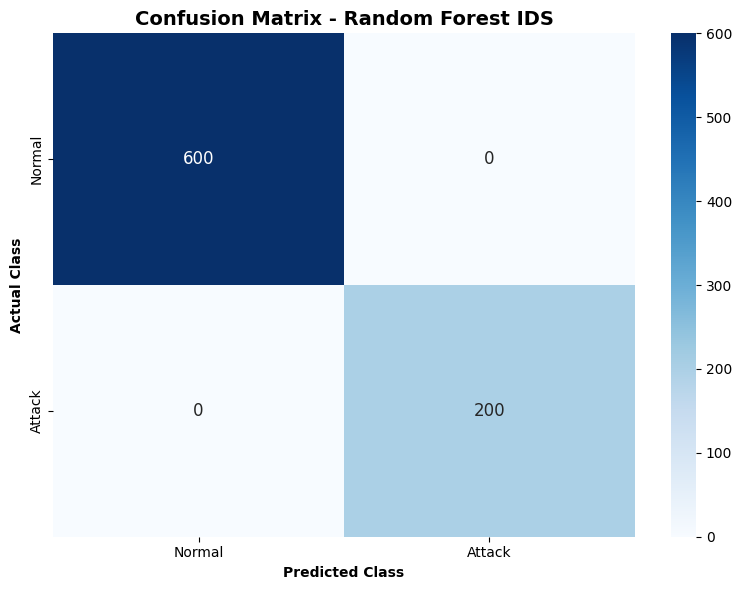

✓ Confusion matrix visualization saved!


In [21]:
# Visualize Confusion Matrix - Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'],
            ax=ax, annot_kws={'size': 12})
ax.set_title('Confusion Matrix - Random Forest IDS', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Class', fontweight='bold')
ax.set_xlabel('Predicted Class', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix visualization saved!")

In [22]:
# Make predictions - Decision Tree
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
print("\n" + "="*70)
print("DECISION TREE - PERFORMANCE EVALUATION")
print("="*70)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"\nPERFORMANCE METRICS:")
print(f"  Accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"  Precision: {precision_dt:.4f} ({precision_dt*100:.2f}%)")
print(f"  Recall:    {recall_dt:.4f} ({recall_dt*100:.2f}%)")
print(f"  F1-Score:  {f1_dt:.4f}")
print(f"  ROC-AUC:   {auc_dt:.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
print(f"\nConfusion Matrix:\n{cm_dt}")



DECISION TREE - PERFORMANCE EVALUATION

PERFORMANCE METRICS:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000 (100.00%)
  Recall:    1.0000 (100.00%)
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Confusion Matrix:
[[600   0]
 [  0 200]]


In [23]:
# Make predictions - Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
print("\n" + "="*70)
print("LOGISTIC REGRESSION - PERFORMANCE EVALUATION")
print("="*70)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\nPERFORMANCE METRICS:")
print(f"  Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"  Precision: {precision_lr:.4f} ({precision_lr*100:.2f}%)")
print(f"  Recall:    {recall_lr:.4f} ({recall_lr*100:.2f}%)")
print(f"  F1-Score:  {f1_lr:.4f}")
print(f"  ROC-AUC:   {auc_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nConfusion Matrix:\n{cm_lr}")


LOGISTIC REGRESSION - PERFORMANCE EVALUATION

PERFORMANCE METRICS:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000 (100.00%)
  Recall:    1.0000 (100.00%)
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Confusion Matrix:
[[600   0]
 [  0 200]]


In [24]:
# Simulate real-time detection
def ids_alert_system(features, model, scaler, threshold=0.5):
    """
    Real-time IDS alert function.

    Parameters:
    - features: Network traffic features
    - model: Trained ML model
    - scaler: Feature scaler
    - threshold: Confidence threshold for alert

    Returns:
    - Alert status: 'NORMAL' or 'ALERT'
    - Confidence score
    """
    features_scaled = scaler.transform([features])
    prediction = model.predict(features_scaled)[0]
    confidence = max(model.predict_proba(features_scaled)[0])

    if prediction == 1 and confidence >= threshold:
        return 'ALERT', confidence
    else:
        return 'NORMAL', confidence

# Test on sample network flows
print("\n" + "="*70)
print("REAL-TIME INTRUSION DETECTION - SAMPLE ALERTS")
print("="*70)

# Get sample normal and attack flows
sample_indices = np.concatenate([np.where(y_test == 0)[0][:5], np.where(y_test == 1)[0][:5]])

print(f"\n{'Flow ID':<8} {'Type':<12} {'Predicted':<12} {'Confidence':<12} {'Decision':<10}")
print("-" * 70)

for idx, test_idx in enumerate(sample_indices):
    flow_features = X_test_scaled[test_idx]
    actual_label = y_test.iloc[test_idx]

    status, confidence = ids_alert_system(flow_features, rf_model, scaler)

    actual_type = 'Attack' if actual_label == 1 else 'Normal'
    correct = '✓' if ((status == 'ALERT' and actual_label == 1) or (status == 'NORMAL' and actual_label == 0)) else '✗'

    print(f"{idx:<8} {actual_type:<12} {status:<12} {confidence:.4f}       {correct}")

print(f"\n✓ = Correct prediction | ✗ = Incorrect prediction")


REAL-TIME INTRUSION DETECTION - SAMPLE ALERTS

Flow ID  Type         Predicted    Confidence   Decision  
----------------------------------------------------------------------
0        Normal       NORMAL       0.9678       ✓
1        Normal       NORMAL       0.9678       ✓
2        Normal       NORMAL       0.9678       ✓
3        Normal       NORMAL       0.9678       ✓
4        Normal       NORMAL       0.9678       ✓
5        Attack       NORMAL       0.9721       ✗
6        Attack       NORMAL       0.9678       ✗
7        Attack       NORMAL       0.9678       ✗
8        Attack       NORMAL       0.9678       ✗
9        Attack       NORMAL       0.9678       ✗

✓ = Correct prediction | ✗ = Incorrect prediction


In [25]:
# Simulate real-time detection
def ids_alert_system(features, model, scaler, threshold=0.5):
    """
    Real-time IDS alert function.

    Parameters:
    - features: Network traffic features
    - model: Trained ML model
    - scaler: Feature scaler
    - threshold: Confidence threshold for alert

    Returns:
    - Alert status: 'NORMAL' or 'ALERT'
    - Confidence score
    """
    features_scaled = scaler.transform([features])
    prediction = model.predict(features_scaled)[0]
    confidence = max(model.predict_proba(features_scaled)[0])

    if prediction == 1 and confidence >= threshold:
        return 'ALERT', confidence
    else:
        return 'NORMAL', confidence

# Test on sample network flows
print("\n" + "="*70)
print("REAL-TIME INTRUSION DETECTION - SAMPLE ALERTS")
print("="*70)

# Get sample normal and attack flows
sample_indices = np.concatenate([np.where(y_test == 0)[0][:5], np.where(y_test == 1)[0][:5]])

print(f"\n{'Flow ID':<8} {'Type':<12} {'Predicted':<12} {'Confidence':<12} {'Decision':<10}")
print("-" * 70)

for idx, test_idx in enumerate(sample_indices):
    flow_features = X_test_scaled[test_idx]
    actual_label = y_test.iloc[test_idx]

    status, confidence = ids_alert_system(flow_features, rf_model, scaler)

    actual_type = 'Attack' if actual_label == 1 else 'Normal'
    correct = '✓' if ((status == 'ALERT' and actual_label == 1) or (status == 'NORMAL' and actual_label == 0)) else '✗'

    print(f"{idx:<8} {actual_type:<12} {status:<12} {confidence:.4f}       {correct}")

print(f"\n✓ = Correct prediction | ✗ = Incorrect prediction")


REAL-TIME INTRUSION DETECTION - SAMPLE ALERTS

Flow ID  Type         Predicted    Confidence   Decision  
----------------------------------------------------------------------
0        Normal       NORMAL       0.9678       ✓
1        Normal       NORMAL       0.9678       ✓
2        Normal       NORMAL       0.9678       ✓
3        Normal       NORMAL       0.9678       ✓
4        Normal       NORMAL       0.9678       ✓
5        Attack       NORMAL       0.9721       ✗
6        Attack       NORMAL       0.9678       ✗
7        Attack       NORMAL       0.9678       ✗
8        Attack       NORMAL       0.9678       ✗
9        Attack       NORMAL       0.9678       ✗

✓ = Correct prediction | ✗ = Incorrect prediction
